# Trial Notebook on Adaptive MH

In [ ]:
!pip install git+https://github.com/Violandree/podcnf

  Cloning https://github.com/Violandree/podcnf to /tmp/pip-req-build-dgtr32bk
  Running command git clone --filter=blob:none --quiet https://github.com/Violandree/podcnf /tmp/pip-req-build-dgtr32bk
  Resolved https://github.com/Violandree/podcnf to commit 6f167fca0fb466d99d7a20878c63e45e36b6ffbf
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Cloning https://github.com/NicolaRFranco/dlroms.git to /tmp/pip-install-f6ybognx/dlroms-nicola-r-franco_484589e674da496f81629c5c7cd5ed3a
  Running command git clone --filter=blob:none --quiet https://github.com/NicolaRFranco/dlroms.git /tmp/pip-install-f6ybognx/dlroms-nicola-r-franco_484589e674da496f81629c5c7cd5ed3a
  Resolved https://github.com/NicolaRFranco/dlroms.git to commit c80bc11584e8a9be566cdec45829177ad83f554a
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━

In [2]:
import os
import gdown
import numpy as np
import torch
from tqdm import tqdm
from scipy.special import logsumexp
import pickle
from time import perf_counter

from torch.distributions.multivariate_normal import MultivariateNormal

from podcnf.DataGenerationLinearElasticity import *
from podcnf.NFmodel import NormalizingFlow
from podcnf.roms import PODcnf, TorchScaler


In [3]:
SEED = 42

In [4]:
if torch.cuda.is_available():
        device = torch.device("cuda")
        torch.cuda.manual_seed_all(SEED)
        torch.backends.cudnn.benchmark = True
        scaler = torch.amp.GradScaler(enabled=True)
else:
    device = torch.device("cpu")
    scaler = torch.amp.GradScaler(enabled=False)

In [5]:
# {'learning_rate': 0.001, 'num_flows': 16, 'hidden_size': 256, 'hidden_depth': 2, 'weight_decacy': 1e-05}
os.makedirs('../results/elastic', exist_ok=True)
target_folder = os.path.join("..", "results/elastic")
MODEL_NAME = os.path.join(target_folder, 'MODEL_64_NEW.pth')
gdown.download(id = "1Mv9opjkEMDQaLBQx07Fqvh_ItyefLsCl", quiet=True, output = MODEL_NAME)
loaded_model = torch.load(MODEL_NAME, map_location=device)

In [6]:
# c_scaler and mu_scaler
c_scaler_path = os.path.join(target_folder, "c_scaler.pkl")
if not os.path.exists(c_scaler_path):
    gdown.download(id="12XBewDNM8SSwPoJxmUuXjUXD3kC3lFBr", quiet=True, output=c_scaler_path)
with open(c_scaler_path, "rb") as file:
    c_scal = pickle.load(file)

mu_scaler_path = os.path.join(target_folder, "mu_scaler.pkl")
if not os.path.exists(mu_scaler_path):
    gdown.download(id="1R2u27onqNzsbkvHPWFlrmRuzXyGod_NJ", quiet=True, output=mu_scaler_path)
with open(mu_scaler_path, "rb") as file:
    mu_scal = pickle.load(file)

/usr/local/lib/python3.12/dist-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.8.0 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


In [7]:
mu_scaler = TorchScaler(mu_scal.mean_, mu_scal.scale_, device)
c_scaler = TorchScaler(c_scal.mean_, c_scal.scale_, device)

In [8]:
dim_x = mu_scal.n_features_in_
dim_y = c_scal.n_features_in_

In [9]:
# Linear model
num_flows = 16
hidden_size = 256
hidden_depth = 2

flow = NormalizingFlow(dim_x, dim_y, num_flows, hidden_size, hidden_depth, device).to(device)
flow.load_state_dict(loaded_model)

<All keys matched successfully>

In [10]:
V_file = os.path.join(target_folder, "V_POD_matrix.pt")
if not os.path.exists(V_file):
    gdown.download(id="1k0WgaeP4hXHJEwOd8Ng9Tv7Pbi2iSa9g", quiet=True, output=V_file)
V = torch.load(V_file, map_location="cpu", weights_only=False)

In [11]:
podcnf = PODcnf(V, flow, mu_scaler, c_scaler)

In [12]:
Nh = V.shape[0]

In [13]:
num_sensors = 31
sur = [0,1] # top-left already added
for j in range(num_sensors-1):
    xy = np.array([np.pow(j+2,2)+j, np.pow(j+2,2)+j+1])
    sur.extend(xy)
surface_idx = np.array(sur)

In [14]:
# P = torch.zeros([Nh,1]).to(device)
# P[surface_idx] = int(1)
# P[:20]

In [15]:
V_sensors = V[surface_idx, :].to(device)
print(V_sensors.shape)

torch.Size([62, 20])


In [16]:
Q = lambda c: c @ V_sensors.T

In [ ]:
def adaptive_metropolis_hastings(
    generator, Q, mu_0, obs,
    N, bounds,
    temperature=1.0, C_0=None, n_0=100, epsilon=1e-6, s_d=None,
    nrep=100, h=0.1, verbose=True
):

    # Device
    device = mu_0.device

    # Initialization
    obs = obs.to(device).unsqueeze(0)
    mu_n = mu_0.clone().detach()
    d = mu_n.shape[0]

    # Pre-allocation
    chain = torch.empty((N, d), dtype=torch.float32, device=device)
    accepted_count = 0

    if C_0 is None:
      C_n = torch.eye(d, dtype=torch.float32, device = device)
    else:
      C_n = torch.as_tensor(C_0, dtype=torch.float32, device=device) * 1e-5

    mu_bar_n = mu_n.detach()
    zero_mean = torch.zeros(d, dtype=torch.float32, device=device)
    scaling_val = (2.38 ** 2) / d if s_d is None else s_d

    log_nrep = torch.log(torch.tensor(nrep, dtype=torch.float32, device=device))

    def compute_log_likelihood(mu_t):
        with torch.no_grad():

            c_samples = generator(mu_t, nrep)

            # Projection on the sensors
            # [N_gen, 20] @ [20, 62] -> [N_gen, 62]
            sensor_sample = Q(c_samples)

            diff = sensor_sample - obs.reshape(1, -1)
            dj2 = diff.pow(2).sum(dim=1) # [N_gen]

            # LogSumExp per stabilità (KDE Likelihood)
            # log( sum(exp(-d^2 / 2h^2)) ) - log(N)
            log_pi = torch.logsumexp(-dj2 / (2 * h**2), dim=0) - np.log(nrep)

            return log_pi.item()

    # Initial value for the Log-likelihood
    log_pi_n = compute_log_likelihood(mu_n)

    # Iteretor configuration
    iterator = range(N)
    if verbose:
        iterator = tqdm(iterator, desc="Adaptive MH")

    # MCMC LOOP
    for i in iterator:
        n = i + 1

        # Proposal Covariance once n>n_0
        if n <= n_0:
            proposal_cov = C_n
        else:
            proposal_cov = scaling_val * C_n + epsilon * torch.eye(d, device=device)

        proposal_cov = (proposal_cov + proposal_cov.T) / 2.0

        proposal_dist = MultivariateNormal(zero_mean, proposal_cov)
        perturbation = proposal_dist.sample()

        Y = mu_n + perturbation

        # Check Prior (Bounds)
        if (Y[0] < bounds['m_min'] or Y[0] > bounds['m_max'] or
            Y[1] < bounds['d_min'] or Y[1] > bounds['d_max']):
            mu_next = mu_n
        else:
            log_pi_Y = compute_log_likelihood(Y)

            # Acceptance ratio
            log_alpha = (log_pi_Y - log_pi_n) / temperature

            if np.log(np.random.rand()) < log_alpha:
                mu_n = Y
                log_pi_n = log_pi_Y
                accepted_count += 1

            mu_next = mu_n

        # Save on the pre-allocated matrix
        chain[i] = mu_n

        # Updating the covariance
        if n > n_0:
            mu_bar_prev = mu_bar_n.clone()
            mu_bar_n = (n * mu_bar_prev + mu_next) / (n + 1)

            dt = (mu_next - mu_bar_prev).reshape(-1, 1)
            term_update = dt @ dt.T
            C_n = ((n - 1) / n) * C_n + (scaling_val / n) * (term_update * (n / (n + 1)) + epsilon * torch.eye(d, device=device))

    if verbose:
      acc_rate = accepted_count / N
      print(f"\nAccpetamce Rate: {acc_rate:.2%}")
    return chain, C_n

In [24]:
n_val = 6081
n_samples = 6400
test_idx = 6304 # np.random.randint(n_val, n_samples)
print(test_idx)

6304


In [25]:
# Load reduced data
target_folder = os.path.join("..", "results", "elastic")
os.makedirs(target_folder, exist_ok=True)
target_folder_data = os.path.join("..", "data")
os.makedirs(target_folder_data, exist_ok=True)
reduced_input_file = os.path.join(target_folder_data, "elastic_data_reduced_6400.pt")
if not os.path.exists(reduced_input_file):
    gdown.download(id="1FX_9MQ1gAG4Xqyo3HGoGW0Tvokuouqdq", quiet=True, output=reduced_input_file)
reduced_dataset = torch.load(reduced_input_file, map_location="cpu", weights_only=True)
mu = reduced_dataset['mu']
c = reduced_dataset['c']

# Load raw data
raw_data_file = os.path.join(target_folder_data, "data_linear_density_2pi.pt")
if not os.path.exists(raw_data_file):
    gdown.download(id="1NYiXCqCNLhB87o3OlAav6YfiAO9qoBnM", quiet=True, output=raw_data_file)
loaded_data = torch.load(raw_data_file, map_location="cpu")
u = loaded_data['u_data']

In [26]:
u_surface_sensor = u[:, surface_idx] # selezione direttamente i sensori sulla superficie
print(u_surface_sensor.shape)

torch.Size([6400, 62])


In [ ]:
bounds = {
    'm_min': 1.0, 'm_max': 2.0,
    'd_min': 0.05, 'd_max': 0.25
}

verbose = True

mu_true_phys = mu[test_idx].numpy()
u_obs = u_surface_sensor[test_idx].to(device)

mu_0 = torch.tensor(
    [torch.rand(1).item() + 1.0, torch.rand(1).item() * 0.1 + 0.15],
    dtype=torch.float32,
    device=device
)

print(f"Index: {test_idx} - True Mass={mu_true_phys[0]:.4f}, True Delta={mu_true_phys[1]:.4f}")
print(f"Initial guess: {mu_0.cpu().numpy()}")

print("\n--- EXPLORATION ---")
initial_cov_expl = torch.tensor([[0.001, 0.0], [0.0, 0.001]], dtype=torch.float32, device=device)

t0 = perf_counter()

chain_exploration, cov_learned = adaptive_metropolis_hastings(
    generator=podcnf.sample_latent_same_mu,
    Q=Q,
    mu_0=mu_0,
    u_obs=u_obs,
    N=10000,
    bounds=bounds,
    temperature=5.0,
    C_0=initial_cov_expl,
    n_0=500,
    s_d=2.4,
    nrep=100,
    h=0.1,
    verbose=verbose
)

t_exp = perf_counter() - t0
print(f"Exploration time: {t_exp:.2f} s")

Index: 6304 - True Mass=1.1811, True Delta=0.2132
Initial guess: [1.7574263 0.1585099]

--- EXPLORATION ---


Adaptive MH: 100%|██████████| 10000/10000 [00:54<00:00, 183.99it/s]


Accpetamce Rate: 28.90%
Exploration time: 54.37 s


In [28]:
best_guess = chain_exploration[-1].clone().detach()

print(f"Best Guess after exploration: {best_guess.cpu().numpy()}")

print("\n--- REFINEMENT ---")
cov_for_refinement = cov_learned + torch.eye(2, device=device) * 1e-6

t1 = perf_counter()

chain_refined, cov_refined = adaptive_metropolis_hastings(
    Gen=podcnf,
    Q=Q,
    mu_0=best_guess,
    u_obs=u_obs,
    N=30000,
    bounds=bounds,
    temperature=1.0,
    C_0=cov_for_refinement,
    n_0=0,
    s_d=0.35,
    nrep=200,
    h=0.03,
    verbose=verbose
)

t_ref = perf_counter() - t1
print(f"Refinement time: {t_ref:.2f} s")

Best Guess after exploration: [1.7674339  0.17347454]

--- REFINEMENT ---


Adaptive MH: 100%|██████████| 30000/30000 [05:28<00:00, 91.44it/s]


Accpetamce Rate: 51.05%
Refinement time: 328.10 s


In [29]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def plot_trace_and_posterior(chain_exp, chain_ref, mu_true, model_name="NF"):
    # Unisce le due catene per il trace plot
    full_chain = np.vstack([chain_exp, chain_ref])
    split_point = len(chain_exp)

    # Burn-in e step per snellire la densità della posterior
    if model_name == "NF":
        clean_samples = chain_ref[2000:]
        step = 200
    else:
        clean_samples = chain_ref[1000:]
        step = 20

    # --- TRACE PLOT ---
    fig1, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Plot Mass
    axes[0].plot(full_chain[:, 0], color='#1f77b4', linewidth=0.8, alpha=0.9, label='Chain')
    axes[0].axvline(x=split_point, color='black', linestyle='--', linewidth=1.5, label='Refinement')
    axes[0].axhline(y=mu_true[0], color='red', linestyle='--', linewidth=2, label='True target')
    axes[0].set_title(f"Trace Plot: Mass ({mu_true[0]:.4f})", fontsize=14, fontweight='bold')
    axes[0].set_ylabel("Mass")
    axes[0].set_xlabel("Iteration")
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # Plot Delta
    axes[1].plot(full_chain[:, 1], color='#ff7f0e', linewidth=0.8, alpha=0.9, label='Chain')
    axes[1].axvline(x=split_point, color='black', linestyle='--', linewidth=1.5)
    axes[1].axhline(y=mu_true[1], color='red', linestyle='--', linewidth=2, label='True target')
    axes[1].set_title(f"Trace Plot: Delta ({mu_true[1]:.4f})", fontsize=14, fontweight='bold')
    axes[1].set_ylabel("Delta")
    axes[1].set_xlabel("Iteration")
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    # --- POSTERIOR DISTRIBUTION ---
    fig2, ax_post = plt.subplots(figsize=(7, 5))
    sns.kdeplot(
        x=clean_samples[:, 0],
        y=clean_samples[:, 1],
        cmap="Blues" if model_name == "NF" else "Oranges",
        fill=True,
        thresh=0.05,
        levels=10,
        ax=ax_post
    )

    ax_post.scatter(mu_true[0], mu_true[1], s=300, c='red', marker='X', label='True target', zorder=10)
    ax_post.scatter(clean_samples[::step, 0], clean_samples[::step, 1], s=5, c='black', alpha=0.1, label='Samples')
    ax_post.set_title(f"Posterior Distribution ({model_name})", fontsize=14, fontweight='bold')
    ax_post.set_xlabel("Mass")
    ax_post.set_ylabel("Delta")
    ax_post.legend()
    ax_post.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

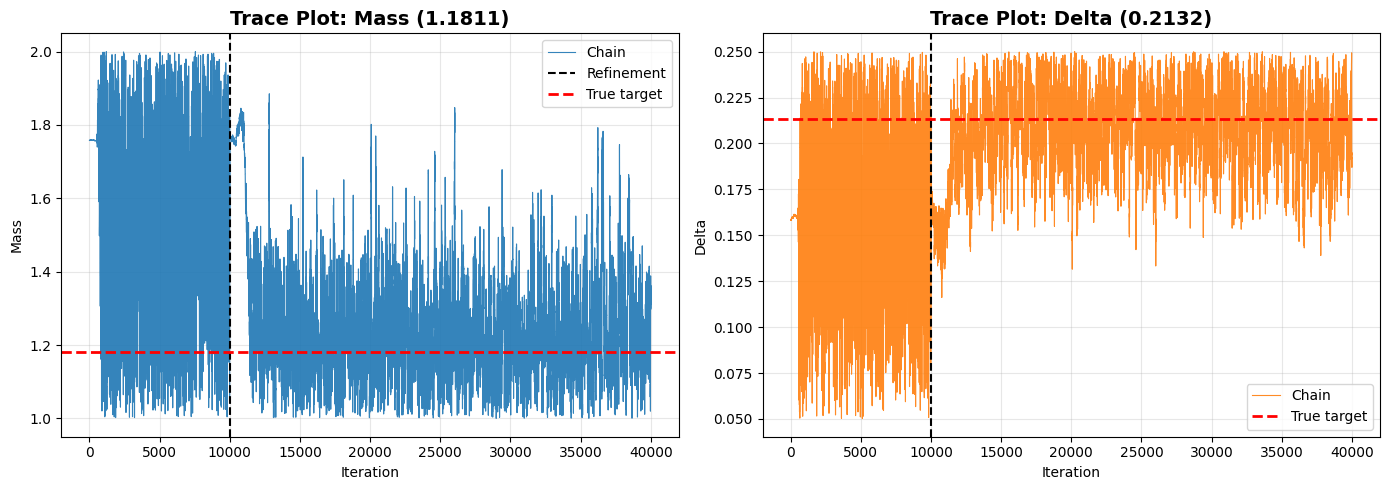

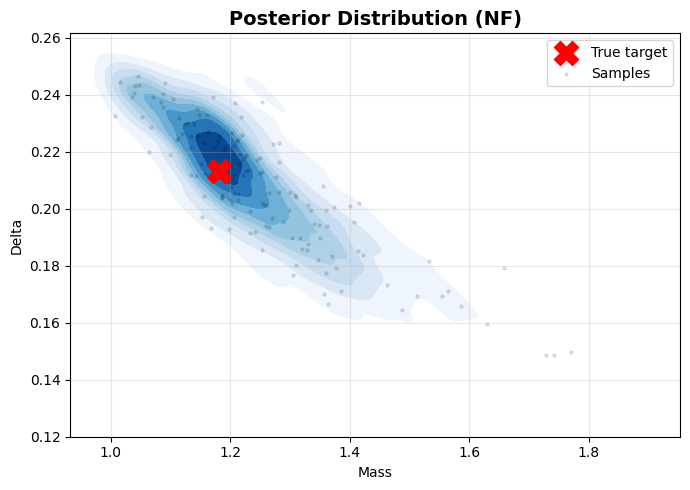

In [30]:
plot_trace_and_posterior(
    chain_exp=chain_exploration.cpu().numpy(),
    chain_ref=chain_refined.cpu().numpy(),
    mu_true=mu_true_phys,
    model_name="NF"
)